## Projet IA   
L’agriculture de précision s’appuie aujourd’hui sur l’IA et le Deep Learning (DL) pour détecter rapidement les maladies des cultures. L’objectif de ce mini-projet est de développer un système automatique basé sur un réseau de neurones convolutif (CNN) capable de distinguer une feuille de pomme de terre saine d’une feuille malade, sans tenir compte du type de maladie.

In [1]:
#importation des bibliotheque
import os
import shutil
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, f1_score

# ==============================================================================
# 0. CONFIGURATION DES CHEMINS
# ==============================================================================

In [2]:
# Si vous rencontrez encore une erreur "FileNotFoundError", remplacez './Potato' 
# par votre chemin absolu, par exemple : r"C:\Users\nzigu\...\UA3_IA\Potato"
base_dir = '.' 
binary_dataset_dir = os.path.join(base_dir, 'Binary_Potato_Dataset')

print("=== DÉMARRAGE DU PIPELINE ===")



=== DÉMARRAGE DU PIPELINE ===


# ==============================================================================
# 1. PRÉTRAITEMENT ET FUSION DES CLASSES (CLASSIFICATION BINAIRE)
# ==============================================================================


In [3]:
print("\n1. Réorganisation des dossiers...")
splits = ['Train', 'Valid', 'Test']

for split in splits:
    split_path = os.path.join(base_dir, split)
    if not os.path.exists(split_path): 
        print(f"  -> Dossier ignoré (introuvable) : {split_path}")
        continue

    # Création des sous-dossiers binaires
    dest_0 = os.path.join(binary_dataset_dir, split, '0_Healthy')
    dest_1 = os.path.join(binary_dataset_dir, split, '1_Diseased')
    os.makedirs(dest_0, exist_ok=True)
    os.makedirs(dest_1, exist_ok=True)

    # Parcours des classes et fusion
    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)
        if not os.path.isdir(class_path): continue

        # healthy va dans 0_Healthy, le reste (Early/Late blight) va dans 1_Diseased
        target_dir = dest_0 if 'healthy' in class_name.lower() else dest_1

        for img in os.listdir(class_path):
            src_img = os.path.join(class_path, img)
            dst_img = os.path.join(target_dir, img)
            if not os.path.exists(dst_img):
                shutil.copy(src_img, dst_img)
                
print("  -> Dossiers binaires prêts.")


1. Réorganisation des dossiers...
  -> Dossiers binaires prêts.


# ==============================================================================
# 2. CHARGEMENT ET NORMALISATION DES DONNÉES
# ==============================================================================

In [4]:
print("\n2. Chargement des images en mémoire...")
BATCH_SIZE = 32
IMAGE_SIZE = (256, 256)

train_dir = os.path.join(binary_dataset_dir, 'Train')
valid_dir = os.path.join(binary_dataset_dir, 'Valid')

# Chargement direct via tf.keras.utils
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, label_mode='binary'
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    valid_dir, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE, label_mode='binary'
)

# Normalisation des pixels (0 à 1)
normalization_layer = layers.Rescaling(1./255)
train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
val_dataset = val_dataset.map(lambda x, y: (normalization_layer(x), y))


2. Chargement des images en mémoire...
Found 900 files belonging to 2 classes.
Found 300 files belonging to 2 classes.


In [5]:
# ==============================================================================
# 3. CONSTRUCTION DU MODÈLE CNN
# ==============================================================================
print("\n3. Construction du modèle CNN...")
model = models.Sequential([
    layers.Input(shape=(256, 256, 3)),
    
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5), # Ajout de Dropout pour l'amélioration
    
    layers.Dense(1, activation='sigmoid') # Sigmoïde pour la classification binaire
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


3. Construction du modèle CNN...


# ==============================================================================
# 4. ENTRAÎNEMENT
# ==============================================================================

In [6]:
print("\n4. Début de l'entraînement...")
EPOCHS = 10 

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)


4. Début de l'entraînement...
Epoch 1/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 250ms/step - accuracy: 0.6444 - loss: 1.0664 - val_accuracy: 0.6667 - val_loss: 0.5623
Epoch 2/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 245ms/step - accuracy: 0.7744 - loss: 0.3879 - val_accuracy: 0.8267 - val_loss: 0.5769
Epoch 3/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 254ms/step - accuracy: 0.7233 - loss: 0.4842 - val_accuracy: 0.9433 - val_loss: 0.2618
Epoch 4/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 248ms/step - accuracy: 0.9178 - loss: 0.2111 - val_accuracy: 0.9433 - val_loss: 0.1245
Epoch 5/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 242ms/step - accuracy: 0.9356 - loss: 0.1426 - val_accuracy: 0.9567 - val_loss: 0.1213
Epoch 6/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 244ms/step - accuracy: 0.9656 - loss: 0.0997 - val_accuracy: 0.9533 - val_loss: 0.1170
Epoch 7/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 249ms/step - accuracy: 0.9733 - loss: 0.0680 - val_accuracy: 0.9633 - val_loss: 0.0645
Epoch 8/10
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 243ms/step - accuracy: 0.9733 - 

# ==============================================================================
# 5. ÉVALUATION ET COURBES D'APPRENTISSAGE
# ==============================================================================


5. Affichage des résultats...


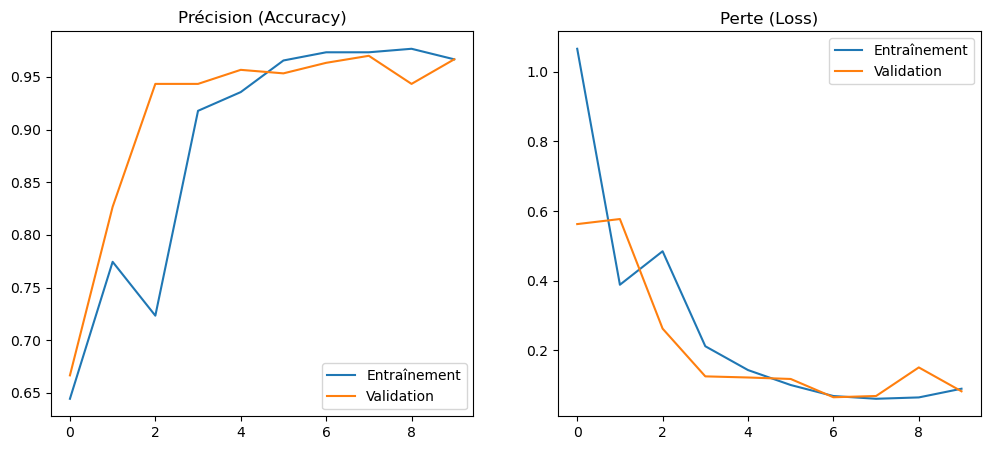

In [7]:
print("\n5. Affichage des résultats...")
# Récupération des données de l'historique
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(EPOCHS)

# Création du graphique
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Entraînement')
plt.plot(epochs_range, val_acc, label='Validation')
plt.legend(loc='lower right')
plt.title('Précision (Accuracy)')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Entraînement')
plt.plot(epochs_range, val_loss, label='Validation')
plt.legend(loc='upper right')
plt.title('Perte (Loss)')
plt.show()

# ==============================================================================
# 6. CALCUL DU F1-SCORE
# ==============================================================================

In [8]:
y_true = []
y_pred_probs = []

for images, labels in val_dataset:
    y_true.extend(labels.numpy().flatten())
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds.flatten())

y_pred = np.array([1 if p > 0.5 else 0 for p in y_pred_probs])

print("\n=== RAPPORT FINAL ===")
print(classification_report(y_true, y_pred, target_names=['Saine - 0', 'Malade - 1']))
print(f"F1-Score Global : {f1_score(y_true, y_pred):.4f}")


=== RAPPORT FINAL ===
              precision    recall  f1-score   support

   Saine - 0       0.95      0.95      0.95       100
  Malade - 1       0.97      0.97      0.97       200

    accuracy                           0.97       300
   macro avg       0.96      0.96      0.96       300
weighted avg       0.97      0.97      0.97       300

F1-Score Global : 0.9750


# ==============================================================================
# 7. ÉVALUATION FINALE SUR LE DATASET DE TEST
# ==============================================================================

In [9]:
print("\n=== ÉVALUATION SUR LES DONNÉES DE TEST ===")

# 1. Définition du chemin vers le dossier Test binaire
test_dir = os.path.join(binary_dataset_dir, 'Test')

# 2. Chargement du dataset de Test
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir, 
    image_size=IMAGE_SIZE, 
    batch_size=BATCH_SIZE, 
    label_mode='binary',
    shuffle=False # On ne mélange pas pour garder l'ordre des vraies étiquettes
)

# 3. Normalisation (Très important : appliquer la même transformation qu'à l'entraînement)
test_dataset = test_dataset.map(lambda x, y: (normalization_layer(x), y))

# 4. Évaluation globale (Loss et Accuracy)
test_loss, test_acc = model.evaluate(test_dataset, verbose=1)
print(f"\nPrécision (Accuracy) sur le Test : {test_acc*100:.2f}%")
print(f"Perte (Loss) sur le Test : {test_loss:.4f}")

# 5. Calcul détaillé du F1-Score sur le Test
y_true_test = []
y_pred_probs_test = []

for images, labels in test_dataset:
    y_true_test.extend(labels.numpy().flatten())
    preds = model.predict(images, verbose=0)
    y_pred_probs_test.extend(preds.flatten())

# Seuil de 0.5 pour la classification binaire
y_pred_test = np.array([1 if p > 0.5 else 0 for p in y_pred_probs_test])

print("\n=== RAPPORT DE CLASSIFICATION (TEST) ===")
print(classification_report(y_true_test, y_pred_test, target_names=['Saine - 0', 'Malade - 1']))
print(f"F1-Score Global (Test) : {f1_score(y_true_test, y_pred_test):.4f}")


=== ÉVALUATION SUR LES DONNÉES DE TEST ===
Found 1200 files belonging to 2 classes.
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.7333 - loss: 1.3042

Précision (Accuracy) sur le Test : 73.33%
Perte (Loss) sur le Test : 1.3042

=== RAPPORT DE CLASSIFICATION (TEST) ===
              precision    recall  f1-score   support

   Saine - 0       0.24      1.00      0.38       100
  Malade - 1       1.00      0.71      0.83      1100

    accuracy                           0.73      1200
   macro avg       0.62      0.85      0.61      1200
weighted avg       0.94      0.73      0.79      1200

F1-Score Global (Test) : 0.8298


# ==============================================================================
# 8. PRÉDICTION SUR UNE NOUVELLE IMAGE (SIMULATION RÉELLE)
# ==============================================================================

In [15]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

#chemin_image = "Potato\Valid\Potato___Late_blight\84182903-22be-4563-8276-d72413958ada___RS_LB 4027.JPG"
def diagnostiquer_feuille(chemin_image, modele):
    """
    Prend le chemin d'une image, la prépare, et utilise le modèle pour 
    prédire si la feuille est saine ou malade.
    """
    print(f"Analyse en cours : {chemin_image}")
    
    # 1. Chargement et redimensionnement (Doit correspondre à IMAGE_SIZE)
    try:
        img = image.load_img(chemin_image, target_size=(256, 256))
    except FileNotFoundError:
        print("Erreur : L'image est introuvable. Vérifiez le chemin.")
        return
        
    # 2. Conversion en matrice de pixels
    img_array = image.img_to_array(img)
    
    # 3. Normalisation (Très important : appliquer la même division par 255 qu'à l'entraînement)
    img_array = img_array / 255.0
    
    # 4. Ajout de la dimension du "batch" -> Le modèle attend (batch_size, 256, 256, 3)
    img_batch = np.expand_dims(img_array, axis=0)
    
    # 5. Prédiction avec le modèle
    prediction_prob = modele.predict(img_batch, verbose=0)[0][0]
    
    # 6. Interprétation du résultat (Seuil à 0.5 avec la fonction Sigmoïde)
    if prediction_prob > 0.5:
        diagnostic = "🚨 Feuille Malade (Classe 1)"
        confiance = prediction_prob * 100
    else:
        diagnostic = "✅ Feuille Saine (Classe 0)"
        confiance = (1 - prediction_prob) * 100
        
    # 7. Affichage visuel du résultat
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{diagnostic} - Confiance : {confiance:.2f}%")
    plt.show()
    
    print(f"-> Résultat final : {diagnostic}")
    print(f"-> Niveau de certitude du modèle : {confiance:.2f}%")

# --- EXEMPLE D'UTILISATION ---
# Copiez-collez le chemin relatif ou absolu d'une image de votre dossier Test
# Par exemple :
# image_a_tester = "./Potato/Test/Potato___Early_blight/une_image_au_hasard.jpg"
# diagnostiquer_feuille(image_a_tester, model)

Analyse en cours : C:\Users\nzigu\Desktop\Projet4\UA3_IA\Potato\Valid\Potato___Early_blight\72013507-bfce-4b7a-b56e-f66a94cb4558___RS_Early.B 7930.JPG


c:\Users\nzigu\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128680 (\N{POLICE CARS REVOLVING LIGHT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


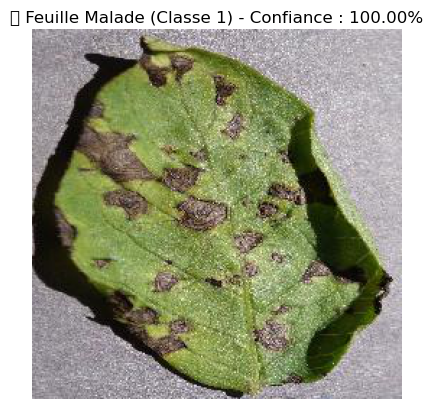

-> Résultat final : 🚨 Feuille Malade (Classe 1)
-> Niveau de certitude du modèle : 100.00%
Analyse en cours : C:\Users\nzigu\Desktop\Projet4\UA3_IA\Potato\Valid\Potato___Early_blight\72013507-bfce-4b7a-b56e-f66a94cb4558___RS_Early.B 7930.JPG


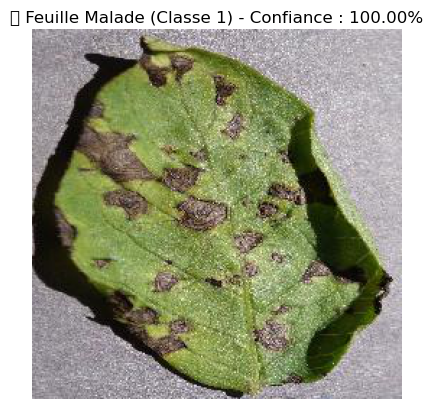

-> Résultat final : 🚨 Feuille Malade (Classe 1)
-> Niveau de certitude du modèle : 100.00%


In [23]:
# 1. Allez dans votre dossier "./Potato/Test/Potato___Early_blight" (ou un autre)
# 2. Copiez le nom exact d'une image qui s'y trouve
# 3. Mettez le chemin complet ici :

mon_image_test = r"C:\Users\nzigu\Desktop\Projet4\UA3_IA\Potato\Valid\Potato___Early_blight\72013507-bfce-4b7a-b56e-f66a94cb4558___RS_Early.B 7930.JPG"

diagnostiquer_feuille(mon_image_test, model)

# 4. On lance l'analyse !
diagnostiquer_feuille(mon_image_test, model)

🚀 DÉMARRAGE DES EXPÉRIENCES...

--- Expérience 1 : Adam | LR = 0.001 | Avec Dropout ---
Epoch 1/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 9s 258ms/step - accuracy: 0.6233 - loss: 0.7999 - val_accuracy: 0.6667 - val_loss: 0.5647
Epoch 2/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 253ms/step - accuracy: 0.7811 - loss: 0.3880 - val_accuracy: 0.9233 - val_loss: 0.2243
Epoch 3/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 259ms/step - accuracy: 0.8800 - loss: 0.2624 - val_accuracy: 0.9600 - val_loss: 0.1790
Epoch 4/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 248ms/step - accuracy: 0.9189 - loss: 0.1838 - val_accuracy: 0.9567 - val_loss: 0.1850
Epoch 5/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 254ms/step - accuracy: 0.9222 - loss: 0.1938 - val_accuracy: 0.9533 - val_loss: 0.1087
Epoch 6/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 274ms/step - accuracy: 0.9589 - loss: 0.1051 - val_accuracy: 0.9800 - val_loss: 0.0501
Epoch 7/15
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 274ms/step - accuracy: 0.9733 - loss: 0.0852 - val_accuracy: 0.7400 - val_loss: 0.3561
Epoch 8/15
29/29

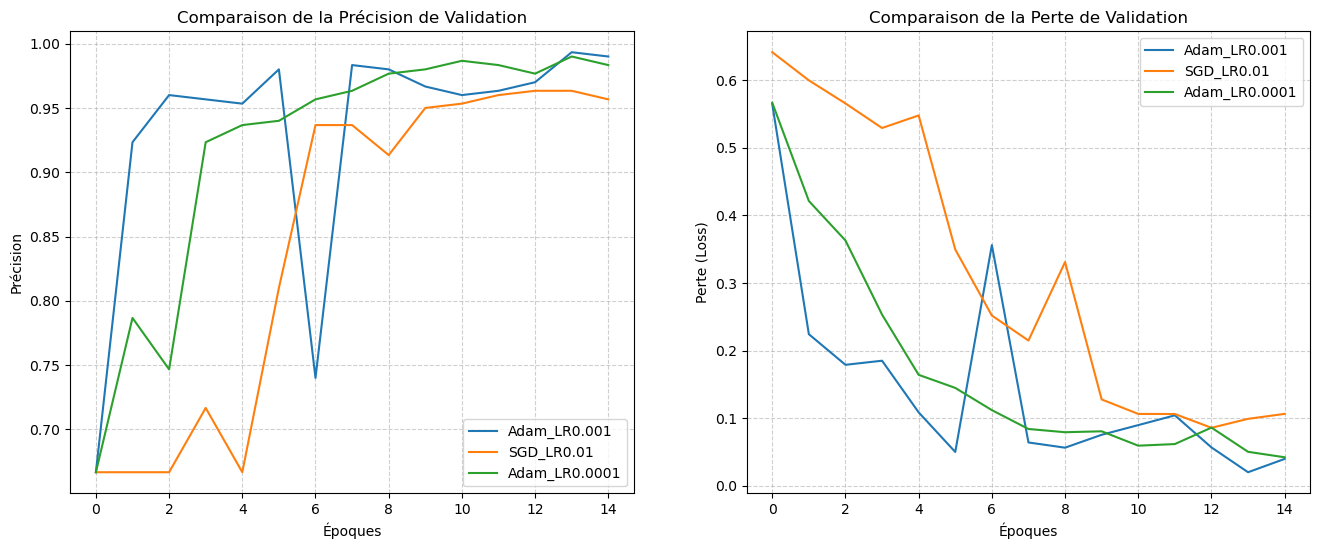

In [13]:
from tensorflow.keras import layers, models, optimizers
import matplotlib.pyplot as plt

# ==============================================================================
# FONCTION POUR CRÉER DES MODÈLES SUR MESURE (POUR L'EXPÉRIMENTATION)
# ==============================================================================
def construire_modele(utilisation_dropout=True, optimiseur='adam', taux_apprentissage=0.001):
    """Construit et compile un modèle avec des hyperparamètres spécifiques."""
    model = models.Sequential([
        layers.Input(shape=(256, 256, 3)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Ajout d'une couche supplémentaire (Point 1 de la consigne)
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Flatten(),
        layers.Dense(128, activation='relu')
    ])
    
    # Utilisation du Dropout (Point 1 de la consigne)
    if utilisation_dropout:
        model.add(layers.Dropout(0.5)) 
        
    model.add(layers.Dense(1, activation='sigmoid'))

    # Choix de l'optimiseur et du taux d'apprentissage (Points 2 et 3 de la consigne)
    if optimiseur.lower() == 'adam':
        opt = optimizers.Adam(learning_rate=taux_apprentissage)
    elif optimiseur.lower() == 'sgd':
        opt = optimizers.SGD(learning_rate=taux_apprentissage)
        
    model.compile(optimizer=opt, loss='binary_crossentropy', metrics=['accuracy'])
    return model

# ==============================================================================
# LANCEMENT DES EXPÉRIENCES
# ==============================================================================
# Point 4 : On ajuste le nombre d'époques à 15 pour voir le comportement à long terme
EPOCHS = 15 
historiques = {}

print("🚀 DÉMARRAGE DES EXPÉRIENCES...\n")

# Expérience 1 : Notre base (Adam classique)
print("--- Expérience 1 : Adam | LR = 0.001 | Avec Dropout ---")
modele_1 = construire_modele(utilisation_dropout=True, optimiseur='adam', taux_apprentissage=0.001)
historiques['Adam_LR0.001'] = modele_1.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS, verbose=1)

# Expérience 2 : Test avec SGD (Généralement plus lent à converger)
print("\n--- Expérience 2 : SGD | LR = 0.01 | Avec Dropout ---")
modele_2 = construire_modele(utilisation_dropout=True, optimiseur='sgd', taux_apprentissage=0.01)
historiques['SGD_LR0.01'] = modele_2.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS, verbose=1)

# Expérience 3 : Test avec Adam mais un taux d'apprentissage plus faible
print("\n--- Expérience 3 : Adam | LR = 0.0001 (Faible) | Avec Dropout ---")
modele_3 = construire_modele(utilisation_dropout=True, optimiseur='adam', taux_apprentissage=0.0001)
historiques['Adam_LR0.0001'] = modele_3.fit(train_dataset, validation_data=val_dataset, epochs=EPOCHS, verbose=1)

# ==============================================================================
# AFFICHAGE DE LA COMPARAISON VISUELLE (IDÉAL POUR LE RAPPORT)
# ==============================================================================
plt.figure(figsize=(16, 6))

# Graphique de Précision (Accuracy)
plt.subplot(1, 2, 1)
for nom, hist in historiques.items():
    plt.plot(hist.history['val_accuracy'], label=f'{nom}')
plt.title('Comparaison de la Précision de Validation')
plt.xlabel('Époques')
plt.ylabel('Précision')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Graphique de Perte (Loss)
plt.subplot(1, 2, 2)
for nom, hist in historiques.items():
    plt.plot(hist.history['val_loss'], label=f'{nom}')
plt.title('Comparaison de la Perte de Validation')
plt.xlabel('Époques')
plt.ylabel('Perte (Loss)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.show()